In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

In [ ]:
ruta = "/content/drive/MyDrive/Tesis.Ecobici.2020-2025/"
archivos = os.listdir(ruta)

print(f"Total de archivos: {len(archivos)}")

Total de archivos: 72


In [ ]:
df_list = []

for file in archivos:
    if file.endswith(".csv"):
        print(f"Procesando: {file}")

        path = ruta + file
        temp = pd.read_csv(path, low_memory=False, encoding='latin1')

        # Detectar columna fecha
        busqueda = ['fecha_retiro', 'fecha_arribo', 'unlocked_at', 'rental start date', 'inicio_del_viaje']
        fecha_col = next((col for col in temp.columns if col.lower() in busqueda), None)

        if fecha_col is None:
            continue

        # Convertir fecha
        temp['fecha'] = pd.to_datetime(temp[fecha_col], dayfirst=True, errors='coerce')
        temp = temp.dropna(subset=['fecha'])

        temp['viajes'] = 1

        temp = temp[['fecha', 'viajes']]

        df_list.append(temp)

Procesando: ecobici_2020_01.csv
Procesando: ecobici_2020_02.csv
Procesando: ecobici_2020_03.csv
Procesando: ecobici_2020_04.csv
Procesando: ecobici_2020_05.csv
Procesando: ecobici_2020_06.csv
Procesando: ecobici_2020_07.csv
Procesando: ecobici_2020_08.csv
Procesando: ecobici_2020_09.csv
Procesando: ecobici_2020_10.csv
Procesando: ecobici_2020_11.csv
Procesando: ecobici_2020_12.csv
Procesando: ecobici_2021_01.csv
Procesando: ecobici_2021_02.csv
Procesando: ecobici_2021_03.csv
Procesando: ecobici_2021_04.csv
Procesando: ecobici_2021_05.csv
Procesando: ecobici_2021_06.csv
Procesando: ecobici_2021_07.csv
Procesando: ecobici_2021_08.csv
Procesando: ecobici_2021_09.csv
Procesando: ecobici_2021_10.csv
Procesando: ecobici_2021_11.csv
Procesando: ecobici_2021_12.csv
Procesando: ecobici_2022_01.csv
Procesando: ecobici_2022_02.csv
Procesando: ecobici_2022_03.csv
Procesando: ecobici_2022_04.csv
Procesando: ecobici_2022_05.csv
Procesando: ecobici_2022_06.csv
Procesando: ecobici_2022_07.csv
Procesan

In [ ]:
df = pd.concat(df_list, ignore_index=True)

print("Shape original:", df.shape)

Shape original: (67893427, 2)


In [ ]:
df['datetime'] = df['fecha'].dt.floor('h')

df_grouped = df.groupby('datetime').agg({
    'viajes': 'sum'
}).reset_index()

print("Shape agrupado:", df_grouped.shape)

Shape agrupado: (2202, 2)


In [ ]:
# Crear rango completo de horas
rango = pd.date_range(
    start=df_grouped['datetime'].min(),
    end=df_grouped['datetime'].max(),
    freq='h'
)

# Reindexar
df_grouped = df_grouped.set_index('datetime').reindex(rango)

# Rellenar con 0
df_grouped['viajes'] = df_grouped['viajes'].fillna(0)

# Regresar datetime
df_grouped = df_grouped.reset_index()
df_grouped.rename(columns={'index': 'datetime'}, inplace=True)

print("Shape después de rellenar:", df_grouped.shape)

Shape después de rellenar: (63433, 2)


In [ ]:
df_grouped['year'] = df_grouped['datetime'].dt.year
df_grouped['mes'] = df_grouped['datetime'].dt.month
df_grouped['hora'] = df_grouped['datetime'].dt.hour
df_grouped['dia_semana'] = df_grouped['datetime'].dt.dayofweek

In [ ]:
df_grouped = df_grouped[
    (df_grouped['datetime'] >= '2020-01-01') &
    (df_grouped['datetime'] <= '2025-12-31')
]

print(df_grouped.shape)
print(df_grouped['year'].unique())

(52585, 6)
[2020 2021 2022 2023 2024 2025]


In [ ]:
df_grouped.to_csv("/content/drive/MyDrive/ecobici_final_correcto.csv", index=False)

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ecobici_final_correcto.csv")

df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

In [ ]:
df['lag_1'] = df['viajes'].shift(1)
df['lag_24'] = df['viajes'].shift(24)
df['lag_168'] = df['viajes'].shift(168)

df = df.dropna()

In [ ]:
df['fin_semana'] = (df['dia_semana'] >= 5).astype(int)

In [ ]:
features = [
    'hora', 'dia_semana', 'mes', 'year',
    'lag_1', 'lag_24', 'lag_168', 'fin_semana'
]

In [ ]:
train = df[df['year'] <= 2023]
val = df[df['year'] == 2024]
test = df[df['year'] == 2025]

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

model.fit(train[features], train['viajes'])

RandomForestRegressor(max_depth=15, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(test[features])

mae = mean_absolute_error(test['viajes'], y_pred)
rmse = np.sqrt(mean_squared_error(test['viajes'], y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 464.5065768982916
RMSE: 2696.855698487795


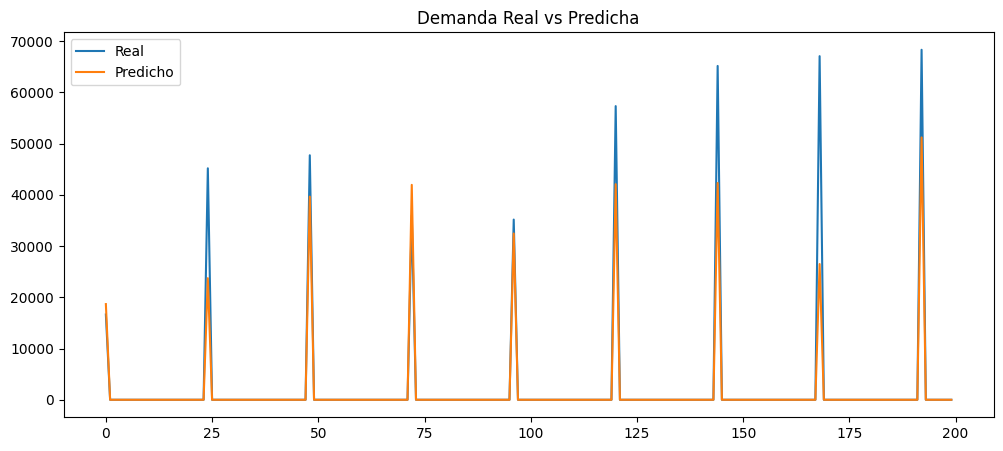

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(test['viajes'].values[:200], label="Real")
plt.plot(y_pred[:200], label="Predicho")
plt.legend()
plt.title("Demanda Real vs Predicha")
plt.show()

In [ ]:
import pandas as pd

importancias = pd.DataFrame({
    'variable': features,
    'importancia': model.feature_importances_
}).sort_values(by='importancia', ascending=False)

print(importancias)

     variable  importancia
6     lag_168     0.946531
5      lag_24     0.044716
1  dia_semana     0.003678
2         mes     0.003145
3        year     0.000870
7  fin_semana     0.000594
0        hora     0.000467
4       lag_1     0.000000


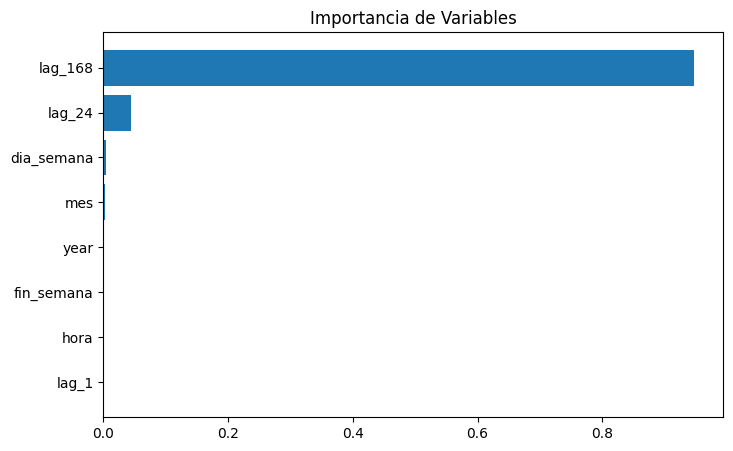

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(importancias['variable'], importancias['importancia'])
plt.gca().invert_yaxis()
plt.title("Importancia de Variables")
plt.show()

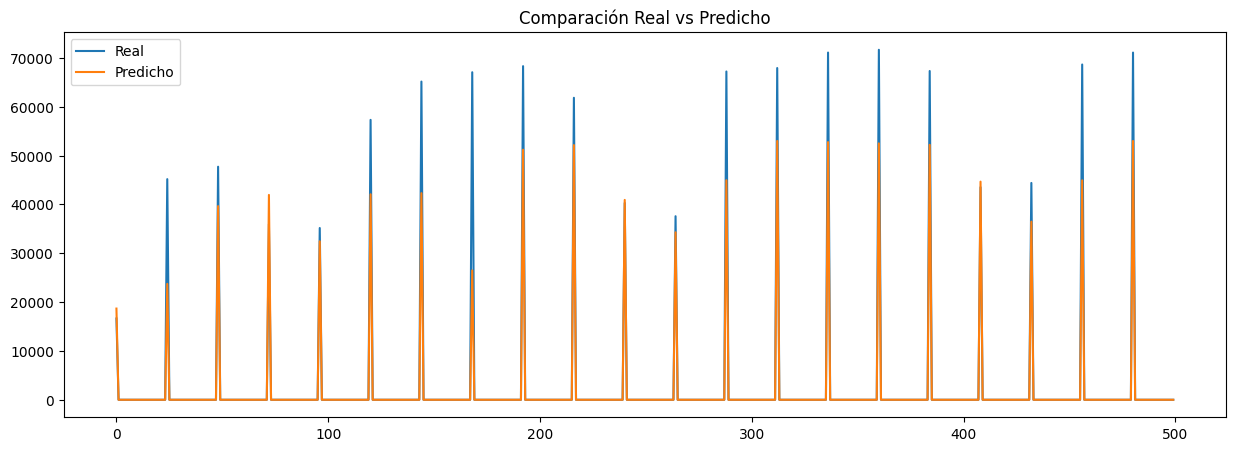

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(test['viajes'].values[:500], label="Real")
plt.plot(y_pred[:500], label="Predicho")
plt.legend()
plt.title("Comparación Real vs Predicho")
plt.show()